# 14_train_evaluate_supervised_ML_models

Run supervised ML training/evaluation across feature combinations, split types, and model choices.

## 1) Environment Setup


In [1]:
from pathlib import Path
import sys

# Section 1: Resolve repo root from either project root or notebooks/ cwd.
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

# Section 2: Add repo and src roots to sys.path for imports.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("repo_root:", repo_root)
print("src_root:", src_root)


repo_root: /Users/charmainechia/Documents/projects/agentic-protein-design
src_root: /Users/charmainechia/Documents/projects/agentic-protein-design/src


## 2) Imports


In [2]:
from pprint import pprint
from project_config.feature_registry import COMBI_ML_FEATURE_SETS
from project_config.variables import address_dict


## 3) Optional Data Segmentation


In [3]:
from agentic_protein_design.tools.ml.segment_data import run_data_segmentation

# Optional: run segmentation before ML.
segmentation_inputs = {
    'run_segmentation': False,
    'root_key': 'PIPS',
    'data_subfolder': 'GOh1052_mutagenesis',
    'csv_file': 'ET096_mutagenesis.csv',
    'output_csv_file': 'ET096_mutagenesis.csv',  # optional override
    'k_folds': 5,
    'mutation_separator': ':',
    'num_mutation_segments_singlemut': 10,
    'max_layer_size_for_multimut_segmentation': None, # [None,1000,500,250],
    'min_layer_size_for_multimut_segmentation': 1000,
    'smallest_single_mutant_size': 80,
    'include_mutation_onehot_for_clustering': True,
    'verbose': True,
}

segmentation_result = {'status': 'skipped', 'output_dataset_fname': None}
if segmentation_inputs['run_segmentation']:
    csv_dir = (repo_root / Path(address_dict[segmentation_inputs['root_key']]) / 'expdata' / segmentation_inputs['data_subfolder']).resolve()
    payload = dict(segmentation_inputs)
    payload['csv_dir'] = str(csv_dir)
    segmentation_result = run_data_segmentation(payload)

print(segmentation_result)


{'status': 'skipped', 'output_dataset_fname': None}


## 4) Configure ML Inputs


In [4]:
import agentic_protein_design.steps.train_evaluate_supervised_ml_models as ml_step
default_user_inputs = ml_step.default_user_inputs
user_inputs = default_user_inputs()

# Edit these for your run
user_inputs['root_key'] = 'PIPS' # 'MUTAGENESIS-DATA-BENCHMARKS' # 'examples' # 'ECOHARVEST' #
user_inputs['data_fbase'] = user_inputs['root_key']
user_inputs['data_subfolder'] = 'GOh1052_mutagenesis' # 'ET096_R1-2' # 'RML_R1' #
user_inputs['csv_suffix'] = '' # '_0' #
default_dataset_fname = user_inputs['data_subfolder'] + '.csv'
user_inputs['dataset_fname'] = segmentation_result.get('output_dataset_fname') or default_dataset_fname

# Experimental data parent folder: address_dict[root_key] / "expdata" / data_subfolder
expdata_dir = (repo_root / Path(address_dict[user_inputs['root_key']]) / 'expdata' / user_inputs['data_subfolder']).resolve()
user_inputs['input_filename_prefix'] = user_inputs['data_subfolder'] + '_' # ''
user_inputs['sequence_base'] = 'sequences/GOh1052.fasta' # "sequences/ET096.fasta" #
user_inputs['target_col'] = ['Fold (Max Abs)'] #  [f'foldchange_{s}_activity_25C' for s in ['NBD','ABTS']] #['foldchange_TSO'] #
user_inputs['classification_or_regression'] = 'regression'

# specify splits
user_inputs['split_type_list'] = ['mutres-modulo', 'random'] # ['custom', 'random'] # ['mutres-modulo', 'custom'] #
user_inputs['k_folds'] = 5
user_inputs['random_kfold_repeats'] = 1  # >1 enables repeated random k-fold from scratch
user_inputs['random_split_col'] = f'fold_random_{user_inputs["k_folds"]}'
user_inputs['mutres_split_col'] = f'fold_mutres-modulo_{user_inputs["k_folds"]}'
user_inputs['contiguous_split_col'] = f'fold_contiguous_{user_inputs["k_folds"]}'  # optional precomputed column
user_inputs['custom_split_col'] = 'fold_custom'
user_inputs['custom_test_value'] = 1
user_inputs['segment_col'] = 'segment_index_0'  # which segmentation column to use
user_inputs['segment_index_range'] = None # [13, None] # [24, 26]; None/[]/[None, None] => full range

# specify custom dataset name
user_inputs['custom_test_dataset_fname'] = None # 'ET096_R3.csv' # ''
user_inputs['custom_test_data_subfolder'] = user_inputs['data_subfolder']
user_inputs['custom_input_filename_prefix'] = None if user_inputs['custom_test_dataset_fname'] is None else user_inputs['custom_test_dataset_fname'].split('.')[0] # ''

# specify featureset combinations to test
# user_inputs['feature_combinations_dict'] = COMBI_ML_FEATURE_SETS
user_inputs['feature_combinations_dict'] = {
    'onehot_esm2_LLR': ['one_hot', 'esm2-650m_LLR-masked'],
    'georgiev_esm2_LLR': ['georgiev', 'esm2-650m_LLR-masked'],
    'esm2_seq_embeddings_LLR': ['esm2-650m_mean_pooled-33', 'esm2-650m_LLR-masked'],
    'onehot_esmc_LLR': ['one_hot', 'esmc-600m_LLR-masked'],
    'georgiev_esmc_LLR': ['georgiev', 'esmc-600m_LLR-masked'],
    'esmc_seq_embeddings_LLR': ['esmc-600m_mean_pooled-36', 'esmc-600m_LLR-masked'],
    'onehot_poet2_LLR': ['one_hot', 'poet2_LLR'],
    'georgiev_poet2_LLR': ['georgiev', 'poet2_LLR'],
    'poet2_seq_embeddings_LLR': ['poet2_mean_pooled-12', 'poet2_LLR'],
    'ponsol2_esm2_LLRsum_entropy_mut_embeddings_MT_proteinmpnn-3_LLRsum_probs_dist_all':[]
}

# specify models
user_inputs['model_list'] =  ['ridge', 'xgboost'] # ['mlp_sklearn', 'mlp_pytorch'] #

# run parameters
# hyperparameter tuning (applied from first fold to subsequent folds in each segment)
user_inputs['hyperparameter_mode'] = 'optuna_search' # 'preset_search' # 'default', 'ntrain_preset',
user_inputs['tuning_metric'] = 'spearman'
user_inputs['tuning_n_trials'] = 20
user_inputs['summary_source_mode'] = 'all_saved_rows'  # 'run_cache' or 'all_saved_rows'
user_inputs['summary_metric_mode'] = 'average'  # 'average' or 'pooled'

# save parameters
user_inputs['save_trained_models'] = False
user_inputs['save_predictions'] = False
user_inputs['train_full_data_model'] = False
user_inputs['featurecombi_model_pair_to_extract_coefficients_for'] = None # [('onehot', 'ridge')]
user_inputs['show_progress'] = True
pprint(user_inputs)


{'classification_or_regression': 'regression',
 'contiguous_split_col': 'fold_contiguous_5',
 'csv_suffix': '',
 'custom_input_filename_prefix': None,
 'custom_split_col': 'fold_custom',
 'custom_test_data_subfolder': 'GOh1052_mutagenesis',
 'custom_test_dataset_fname': None,
 'custom_test_value': 1,
 'data_fbase': 'PIPS',
 'data_subfolder': 'GOh1052_mutagenesis',
 'dataset_fname': 'GOh1052_mutagenesis.csv',
 'feature_combinations_dict': {'esm2_seq_embeddings_LLR': ['esm2-650m_mean_pooled-33',
                                                           'esm2-650m_LLR-masked'],
                               'esmc_seq_embeddings_LLR': ['esmc-600m_mean_pooled-36',
                                                           'esmc-600m_LLR-masked'],
                               'georgiev_esm2_LLR': ['georgiev',
                                                     'esm2-650m_LLR-masked'],
                               'georgiev_esmc_LLR': ['georgiev',
                                      

## 5) Run Training And Evaluation


In [6]:
import importlib

import agentic_protein_design.tools.ml.model_registry as model_registry
import agentic_protein_design.tools.ml.hyperparameter_tuning as hyperparameter_tuning
import agentic_protein_design.tools.ml.workflow as workflow
import agentic_protein_design.steps.train_evaluate_supervised_ml_models as ml_step

importlib.reload(model_registry)
importlib.reload(hyperparameter_tuning)
importlib.reload(workflow)
ml_step = importlib.reload(ml_step)

result = ml_step.train_evaluate_supervised_ml_models(user_inputs)
pprint(result)


[I 2026-04-04 14:48:22,555] A new study created in memory with name: no-name-3dd7a323-1dbf-4db0-9c26-c58e1cb9b86b
[I 2026-04-04 14:48:22,629] Trial 0 finished with value: 0.8811188811188813 and parameters: {'reg_strength': 0.7459343285726545}. Best is trial 0 with value: 0.8811188811188813.
[I 2026-04-04 14:48:22,633] Trial 1 finished with value: 0.7202797202797203 and parameters: {'reg_strength': 566.9849511478844}. Best is trial 0 with value: 0.8811188811188813.
[I 2026-04-04 14:48:22,638] Trial 2 finished with value: 0.8111888111888113 and parameters: {'reg_strength': 45.70563099801449}. Best is trial 0 with value: 0.8811188811188813.
[I 2026-04-04 14:48:22,642] Trial 3 finished with value: 0.8321678321678322 and parameters: {'reg_strength': 9.846738873614559}. Best is trial 0 with value: 0.8811188811188813.
[I 2026-04-04 14:48:22,647] Trial 4 finished with value: 0.8811188811188813 and parameters: {'reg_strength': 0.06026889128682511}. Best is trial 0 with value: 0.8811188811188813

[eval-start] target_col=Fold (Max Abs) | split_type=mutres-modulo | feature_combi_name=onehot_esm2_LLR | model_name=ridge
[tuning-trial] model=ridge | metric=spearman | trial=1/20 | value=0.881119 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=2/20 | value=0.720280 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=3/20 | value=0.811189 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=4/20 | value=0.832168 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=5/20 | value=0.881119 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=6/20 | value=0.881119 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=7/20 | value=0.881119 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=8/20 | value=0.776224 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=9/20 | value=0.832168 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=10/20 

[I 2026-04-04 14:48:22,683] Trial 11 finished with value: 0.8811188811188813 and parameters: {'reg_strength': 0.3636380361432795}. Best is trial 0 with value: 0.8811188811188813.
[I 2026-04-04 14:48:22,688] Trial 12 finished with value: 0.8811188811188813 and parameters: {'reg_strength': 0.26947347017613676}. Best is trial 0 with value: 0.8811188811188813.
[I 2026-04-04 14:48:22,693] Trial 13 finished with value: 0.8811188811188813 and parameters: {'reg_strength': 0.011112001685432533}. Best is trial 0 with value: 0.8811188811188813.
[I 2026-04-04 14:48:22,697] Trial 14 finished with value: 0.8671328671328673 and parameters: {'reg_strength': 1.5664268600857336}. Best is trial 0 with value: 0.8811188811188813.
[I 2026-04-04 14:48:22,701] Trial 15 finished with value: 0.8811188811188813 and parameters: {'reg_strength': 0.0814806068869624}. Best is trial 0 with value: 0.8811188811188813.
[I 2026-04-04 14:48:22,705] Trial 16 finished with value: 0.8811188811188813 and parameters: {'reg_str

[tuning-trial] model=ridge | metric=spearman | trial=12/20 | value=0.881119 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=13/20 | value=0.881119 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=14/20 | value=0.881119 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=15/20 | value=0.867133 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=16/20 | value=0.881119 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=17/20 | value=0.881119 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=18/20 | value=0.867133 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=19/20 | value=0.881119 | best=0.881119
[tuning-trial] model=ridge | metric=spearman | trial=20/20 | value=0.881119 | best=0.881119
[tuning-complete] model=ridge | metric=spearman | direction=maximize | best_value=0.881119 | n_trials=20
[tuning-selected] model=ridge | selected_hyperparameters={'max_iter

[I 2026-04-04 14:48:22,896] A new study created in memory with name: no-name-79de3612-1509-4302-8646-d345fe28c214
[I 2026-04-04 14:48:22,903] Trial 0 finished with value: 0.6422996910127051 and parameters: {'reg_strength': 0.7459343285726545}. Best is trial 0 with value: 0.6422996910127051.
[I 2026-04-04 14:48:22,910] Trial 1 finished with value: 0.6243018012470253 and parameters: {'reg_strength': 566.9849511478844}. Best is trial 0 with value: 0.6422996910127051.
[I 2026-04-04 14:48:22,918] Trial 2 finished with value: 0.6347068312678089 and parameters: {'reg_strength': 45.70563099801449}. Best is trial 0 with value: 0.6422996910127051.
[I 2026-04-04 14:48:22,924] Trial 3 finished with value: 0.6344256142402203 and parameters: {'reg_strength': 9.846738873614559}. Best is trial 0 with value: 0.6422996910127051.
[I 2026-04-04 14:48:22,930] Trial 4 finished with value: 0.6422996910127051 and parameters: {'reg_strength': 0.06026889128682511}. Best is trial 0 with value: 0.6422996910127051

...

[tuning-trial] model=ridge | metric=spearman | trial=13/20 | value=0.851430 | best=0.851852
[tuning-trial] model=ridge | metric=spearman | trial=14/20 | value=0.851536 | best=0.851852
[tuning-trial] model=ridge | metric=spearman | trial=15/20 | value=0.851193 | best=0.851852


[I 2026-04-04 14:48:28,350] Trial 15 finished with value: 0.8524553396755377 and parameters: {'reg_strength': 2.132880946276586}. Best is trial 15 with value: 0.8524553396755377.
[I 2026-04-04 14:48:28,421] Trial 16 finished with value: 0.8522844120848324 and parameters: {'reg_strength': 3.152665086201344}. Best is trial 15 with value: 0.8524553396755377.
[I 2026-04-04 14:48:28,502] Trial 17 finished with value: 0.8523448941553896 and parameters: {'reg_strength': 3.082497730050897}. Best is trial 15 with value: 0.8524553396755377.


[tuning-trial] model=ridge | metric=spearman | trial=16/20 | value=0.852455 | best=0.852455
[tuning-trial] model=ridge | metric=spearman | trial=17/20 | value=0.852284 | best=0.852455
[tuning-trial] model=ridge | metric=spearman | trial=18/20 | value=0.852345 | best=0.852455


[W 2026-04-04 14:48:28,675] Trial 18 failed with parameters: {'reg_strength': 2.9731820838102987} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/charmainechia/miniconda3/envs/agentic-protein-design/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/Users/charmainechia/Documents/projects/agentic-protein-design/src/agentic_protein_design/tools/ml/hyperparameter_tuning.py", line 135, in objective
    model.fit(X_subtrain, y_subtrain)
  File "/Users/charmainechia/miniconda3/envs/agentic-protein-design/lib/python3.11/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/charmainechia/miniconda3/envs/agentic-protein-design/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py", line 1264, in fit
    return super(

KeyboardInterrupt: 

## 6) Visualize ML Results


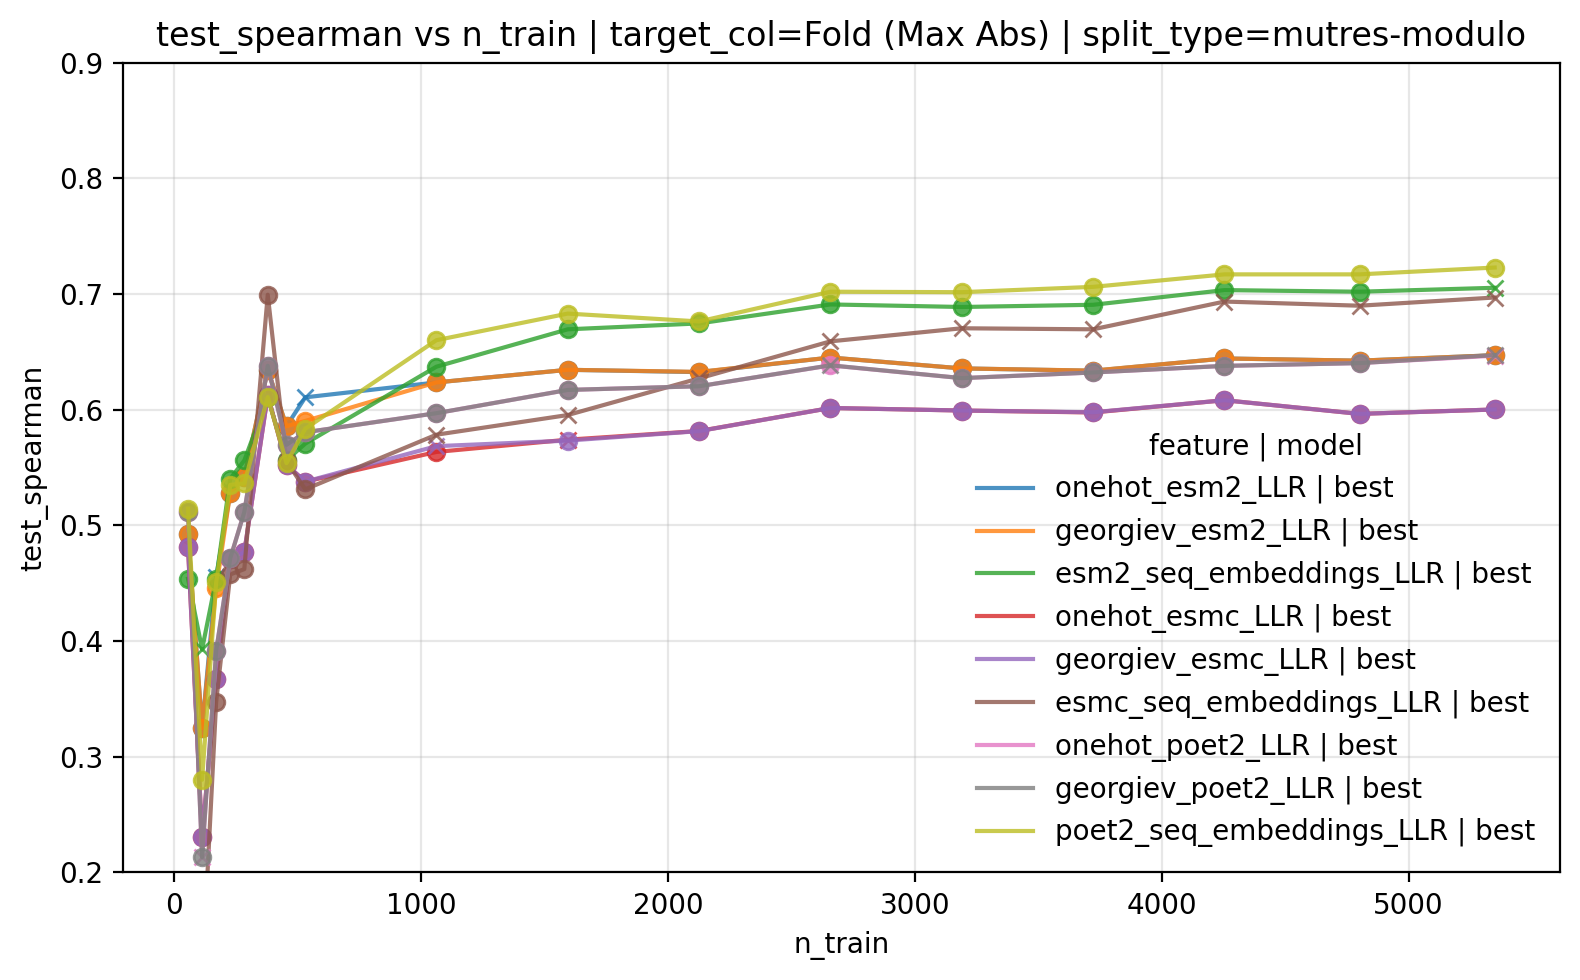

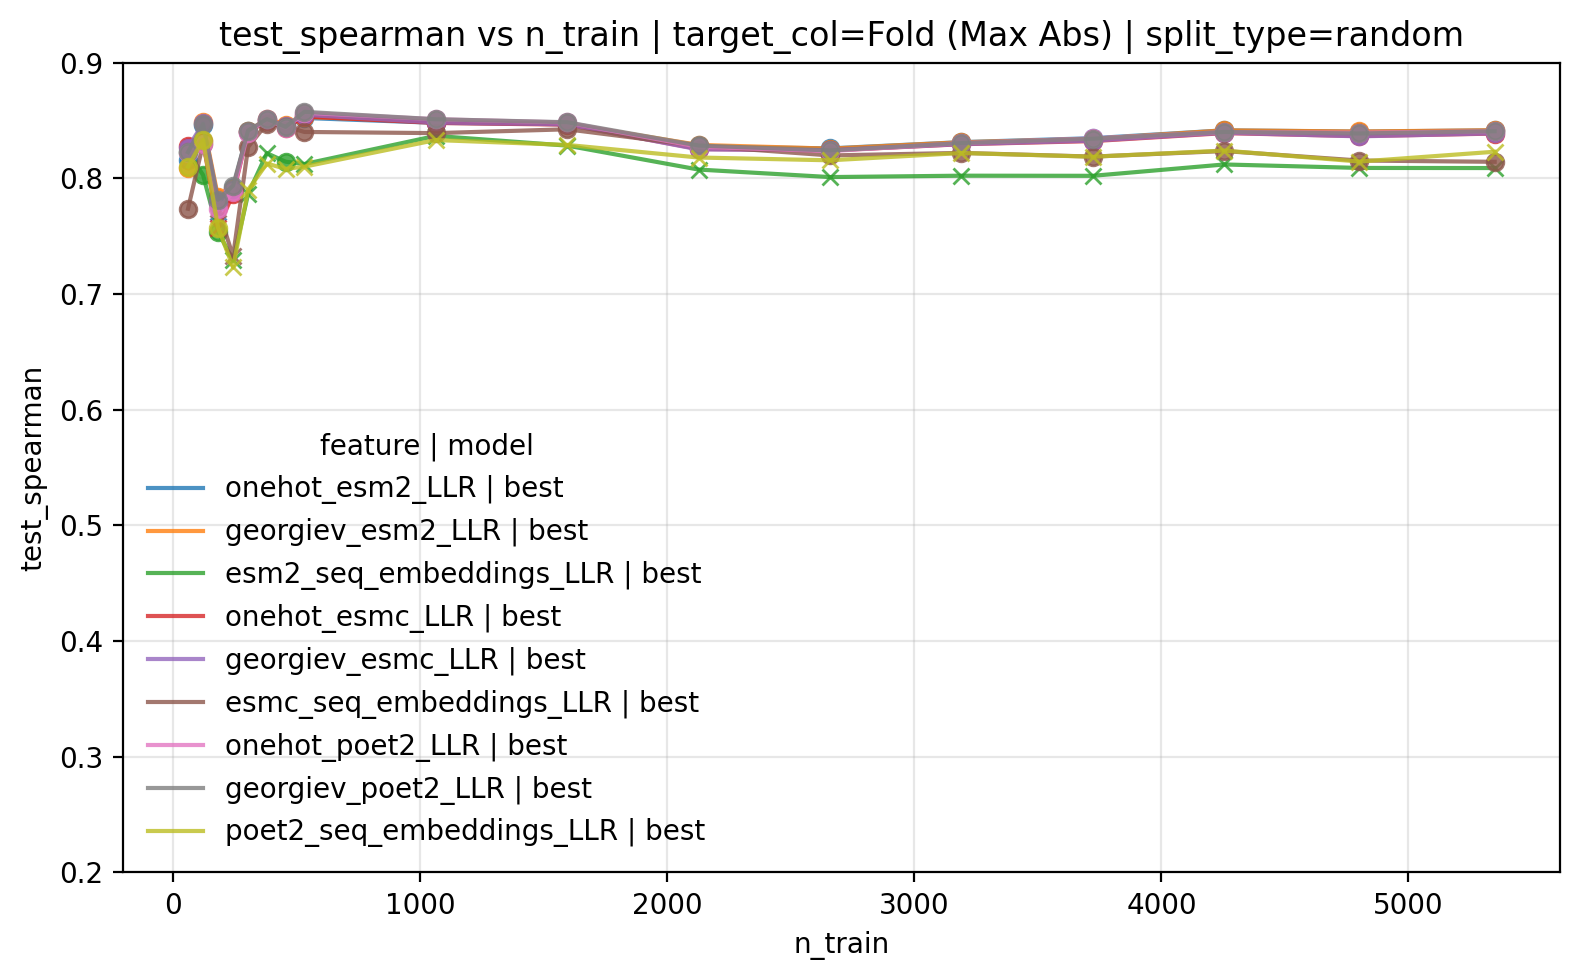

{'figure_paths': ['/Users/charmainechia/Documents/projects/PIPS/PIPS-GalOx-data/ml/output/GOh1052_mutagenesis/data_efficiency_test_spearman_Fold '
                  '(Max Abs)_mutres-modulo_best.png',
                  '/Users/charmainechia/Documents/projects/PIPS/PIPS-GalOx-data/ml/output/GOh1052_mutagenesis/data_efficiency_test_spearman_Fold '
                  '(Max Abs)_random_best.png'],
 'metric_col_list': ['test_spearman'],
 'n_filtered_rows': 748,
 'n_plot_rows_total': 306,
 'n_summary_rows': 748,
 'plotted_pairs': [{'metric_col': 'test_spearman',
                    'n_lines': 9,
                    'n_rows': 153,
                    'split_type': 'mutres-modulo',
                    'target_col': 'Fold (Max Abs)'},
                   {'metric_col': 'test_spearman',
                    'n_lines': 9,
                    'n_rows': 153,
                    'split_type': 'random',
                    'target_col': 'Fold (Max Abs)'}],
 'skipped_pairs': [],
 'split_type_list': ['mut

In [6]:
from pprint import pprint

import agentic_protein_design.steps.visualize_ml_results as ml_viz_step

visualize_ml_results = ml_viz_step.visualize_ml_results
default_viz_inputs = ml_viz_step.default_user_inputs

viz_inputs = default_viz_inputs()
viz_inputs['data_fbase'] = user_inputs.get('data_fbase', 'examples')
viz_inputs['data_subfolder'] = user_inputs.get('data_subfolder', '')
viz_inputs['metrics_summary_fname'] = f"{user_inputs['classification_or_regression']}_metrics_summary{user_inputs.get('csv_suffix', '')}.csv"
viz_inputs['model_name_list'] =  ['best'] #  ['xgboost', 'ridge'] #
viz_inputs['metric_col'] = ['test_spearman']  # string or list
viz_inputs['target_col_list'] = user_inputs.get('target_col', []) if isinstance(user_inputs.get('target_col', []), list) else [user_inputs.get('target_col')]
viz_inputs['split_type_list'] = [] # [] -> iterate all split types in summary CSV
viz_inputs['feature_label_list'] = list(user_inputs['feature_combinations_dict'].keys())
viz_inputs['show_model_type'] = True  # True -> marker shape based on model type
viz_inputs['save_figure'] = True
viz_inputs['show_figure'] = True
viz_inputs['figure_output_dir'] = ''  # default: summary csv folder
viz_inputs['figure_fname'] = ''       # default auto name
viz_inputs['x_limits'] = [0, None]  # e.g. [0, 10000]; None/[] uses matplotlib defaults
viz_inputs['y_limits'] = [0.2, 0.9]      # e.g. [0.0, 1.0]; None/[] uses matplotlib defaults

# Optional override:
viz_inputs['metrics_summary_csv_path'] = '/Users/charmainechia/Documents/projects/PIPS/PIPS-GalOx-data/ml/output/GOh1052_mutagenesis/regression_metrics_summary_ALL.csv'

viz_result = visualize_ml_results(viz_inputs)
pprint(viz_result)


In [10]:
viz_inputs['feature_label_list']

['onehot_esm2_LLR',
 'georgiev_esm2_LLR',
 'esm2_seq_embeddings_LLR',
 'onehot_esmc_LLR',
 'georgiev_esmc_LLR',
 'esmc_seq_embeddings_LLR',
 'onehot_poet2_LLR',
 'georgiev_poet2_LLR',
 'poet2_seq_embeddings_LLR',
 'ponsol2_esm2_LLRsum_entropy_mut_embeddings_MT_proteinmpnn-3_LLRsum_probs_dist_all']